In [1]:
import os
import glob
import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize
from itertools import cycle, islice
from scipy.stats import chi2_contingency, wilcoxon
from scipy.signal import find_peaks

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%matplotlib notebook

In [3]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
cell_table_path = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\data\slap2_cell_table.pkl")

# registry selection
use_all_registry_sessions = True
exclude_session_types = None          # e.g. ["expression_check", "volume_imaging"]
restrict_to_paradigm = None           # e.g. "change_detection_passive"

# analysis thresholds
alpha = 0.05
responsive_alpha = 0.01               # tighter than the selectivity threshold
baseline_slice = slice(25, 50)
response_slice = slice(50, 150)

n_example_somas = 8
smooth_window = 5
min_events_per_image = 3
min_trials_per_image_responsive = 5   # tighter requirement for calling responsiveness
min_fraction_positive = 0.50          # require consistent positive trial responses
n_perm = 1000

session_order = ["familiar", "novel", "novel+"]

# if you already defined image_palette in the notebook, this cell will use it.
# otherwise fall back to a PNW palette.
try:
    image_palette
except NameError:
    _, _, image_palette = PNW_cmap.get_PNW_cmap("Sailboat", n_colors=7)

In [4]:
def fdr_bh(pvals):
    """Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    good = np.isfinite(pvals)
    if good.sum() == 0:
        return qvals

    p = pvals[good]
    order = np.argsort(p)
    ranked = p[order]
    n = len(ranked)

    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    qvals[np.where(good)[0][order]] = q
    return qvals


def smooth_trace(x, window=7):
    x = np.asarray(x, dtype=float)
    return pd.Series(x).rolling(window, center=True, min_periods=1).mean().to_numpy()


def find_first_existing(asset, filename):
    """Look in the expected calcium folder first, then recursively under derived_dir."""
    direct = asset.derived_dir / "calcium" / filename
    if direct.exists():
        return direct

    hits = sorted(asset.derived_dir.rglob(filename))
    return hits[0] if hits else None


def get_depth_from_asset(asset, dmd_name, fallback=np.nan):
    key = f"{dmd_name.lower()}_depth"   # e.g. dmd1_depth / dmd2_depth
    val = asset.metadata.get(key, fallback)
    try:
        return float(val)
    except Exception:
        return fallback


def one_way_fve(y, labels):
    """
    Fraction of variance explained by image identity for scalar per-trial responses.
    Equivalent to between-group SS / total SS.
    """
    y = np.asarray(y, dtype=float)
    labels = np.asarray(labels)

    good = np.isfinite(y)
    y = y[good]
    labels = labels[good]

    if y.size < 3 or np.unique(labels).size < 2:
        return np.nan

    grand_mean = y.mean()
    total_ss = np.sum((y - grand_mean) ** 2)
    if total_ss <= 0:
        return np.nan

    between_ss = 0.0
    for lab in np.unique(labels):
        vals = y[labels == lab]
        between_ss += len(vals) * (vals.mean() - grand_mean) ** 2

    return between_ss / total_ss


def responsive_test_from_single_trials(
    image_trial_dict,
    roi_idx,
    baseline_slice,
    response_slice,
    alpha=0.01,
    min_events_per_image=8,
    min_fraction_positive=0.60,
):
    """
    Conservative image-responsiveness test using single-trial responses.

    For each image:
      1) compute per-trial amplitude = mean(response window) - mean(baseline window)
      2) test whether amplitudes are > 0 with a one-sided Wilcoxon signed-rank test
      3) apply BH-FDR across images for that soma
      4) require both statistical significance and a minimum fraction of positive trials

    This is intentionally stricter than testing many correlated time samples from
    the mean trace against baseline.
    """
    rows = []

    for image_name, arr in image_trial_dict.items():
        arr = np.asarray(arr, dtype=float)

        if arr.ndim != 3:
            continue
        if roi_idx >= arr.shape[1]:
            continue

        roi_trials = arr[:, roi_idx, :]  # trials x time

        with np.errstate(invalid="ignore"):
            base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
            resp = np.nanmean(roi_trials[:, response_slice], axis=1)

        delta = resp - base
        keep = np.isfinite(delta)
        delta = delta[keep]

        if len(delta) < min_events_per_image:
            rows.append(
                {
                    "image_name": image_name,
                    "n_trials": len(delta),
                    "median_delta": np.nan,
                    "mean_delta": np.nan,
                    "frac_positive": np.nan,
                    "p": np.nan,
                }
            )
            continue

        frac_positive = np.mean(delta > 0)
        median_delta = np.median(delta)
        mean_delta = np.mean(delta)

        if np.allclose(delta, 0):
            p = 1.0
        else:
            try:
                p = wilcoxon(delta, alternative="greater", zero_method="wilcox").pvalue
            except ValueError:
                p = 1.0

        rows.append(
            {
                "image_name": image_name,
                "n_trials": len(delta),
                "median_delta": median_delta,
                "mean_delta": mean_delta,
                "frac_positive": frac_positive,
                "p": p,
            }
        )

    df = pd.DataFrame(rows)

    if df.empty:
        return False, np.nan, np.nan, df

    df["q"] = fdr_bh(df["p"].to_numpy())
    df["responsive_image"] = (
        (df["q"] < alpha)
        & (df["median_delta"] > 0)
        & (df["frac_positive"] >= min_fraction_positive)
    )

    responsive = bool(df["responsive_image"].any())

    if responsive:
        best_idx = df["median_delta"].astype(float).idxmax()
        best_image = df.loc[best_idx, "image_name"]
        best_delta = df.loc[best_idx, "median_delta"]
    else:
        best_image = np.nan
        best_delta = np.nan

    return responsive, best_image, best_delta, df


def image_selectivity_from_single_trials(
    image_trial_dict,
    roi_idx,
    baseline_slice,
    response_slice,
    min_events_per_image=5,
    n_perm=1000,
    rng=None,
):
    """
    Use single-trial response amplitudes:
        mean(response window) - mean(baseline window)
    and compute image FVE with a permutation test.
    """
    rng = np.random.default_rng(None if rng is None else rng)

    y_list = []
    label_list = []
    per_image_rows = []

    for image_name, arr in image_trial_dict.items():
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 3:
            continue
        if roi_idx >= arr.shape[1]:
            continue

        roi_trials = arr[:, roi_idx, :]  # trials x time

        with np.errstate(invalid="ignore"):
            base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
            resp = np.nanmean(roi_trials[:, response_slice], axis=1)

        y = resp - base
        y = y[np.isfinite(y)]

        if len(y) < min_events_per_image:
            continue

        y_list.append(y)
        label_list.append(np.repeat(image_name, len(y)))

        per_image_rows.append(
            {
                "image_name": image_name,
                "n_events": len(y),
                "mean_trial_response": np.mean(y),
                "std_trial_response": np.std(y, ddof=1) if len(y) > 1 else np.nan,
            }
        )

    per_image_df = pd.DataFrame(per_image_rows)

    if len(y_list) < 2:
        return np.nan, np.nan, np.nan, per_image_df

    y = np.concatenate(y_list)
    labels = np.concatenate(label_list)

    obs_fve = one_way_fve(y, labels)

    if not np.isfinite(obs_fve):
        return np.nan, np.nan, len(y), per_image_df

    perm_fve = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm_fve[i] = one_way_fve(y, rng.permutation(labels))

    p = (1 + np.sum(perm_fve >= obs_fve)) / (n_perm + 1)
    return obs_fve, p, len(y), per_image_df


def rate_table(df, group_col, flag_col, order=None):
    out = (
        df.groupby(group_col, dropna=False)[flag_col]
        .agg(["sum", "count", "mean"])
        .rename(columns={"sum": "n_true", "count": "n_total", "mean": "fraction"})
        .reset_index()
    )
    out["sem"] = np.sqrt(out["fraction"] * (1 - out["fraction"]) / out["n_total"].clip(lower=1))

    if order is not None:
        present = [x for x in order if x in out[group_col].tolist()]
        others = [x for x in out[group_col].tolist() if x not in present]
        cat_order = present + sorted(others)
        out[group_col] = pd.Categorical(out[group_col], categories=cat_order, ordered=True)
        out = out.sort_values(group_col)

    return out


def chi2_report(df, group_col, flag_col):
    tab = pd.crosstab(df[group_col], df[flag_col])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan, np.nan, np.nan, tab
    chi2, p, dof, _ = chi2_contingency(tab)
    return chi2, p, dof, tab

In [5]:
registry = VIPSessionRegistry.from_basepath(basepath)

process_df = registry.sessions().copy()

if exclude_session_types is not None:
    process_df = process_df[
        ~process_df["session_type"].isin(exclude_session_types)
    ].copy()

if restrict_to_paradigm is not None and "paradigm" in process_df.columns:
    process_df = process_df[
        process_df["paradigm"] == restrict_to_paradigm
    ].copy()

process_df = process_df.reset_index(drop=True)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

with open(cell_table_path, "rb") as f:
    cell_table = pickle.load(f)

cell_table = cell_table.copy()
cell_table["session_id"] = cell_table["session_id"].astype(str)
cell_table = cell_table[cell_table["valid_roi"]].copy()

# keep only soma that belong to sessions in the current registry selection
selected_session_ids = set(process_df["session_id"].astype(str))
cell_table = cell_table[cell_table["session_id"].isin(selected_session_ids)].copy()

print(f"Selected {len(process_df)} sessions across {process_df['subject_id'].nunique()} mice")
print(f"Cell table rows retained for selected sessions: {len(cell_table)}")

# examples: rank all valid soma by SNR, skip the very top one because it is bad
example_candidates = (
    cell_table.sort_values("robust_snr", ascending=False)
    .iloc[1 : 1 + n_example_somas]
    .copy()
)
example_keys = {
    (str(row.session_id), str(row.fov_id), int(row.roi_id))
    for _, row in example_candidates.iterrows()
}

Selected 103 sessions across 22 mice
Cell table rows retained for selected sessions: 85


In [6]:
records = []
example_payloads = []
missing_assets = []

for asset in assets:
    mean_path = find_first_existing(asset, "calcium_mean_dff.npz")
    single_path = find_first_existing(asset, "calcium_single_trial_dff.npz")

    if mean_path is None or single_path is None:
        missing_assets.append(
            {
                "session_id": getattr(asset, "session_id", "unknown"),
                "mean_found": mean_path is not None,
                "single_found": single_path is not None,
            }
        )
        continue

    mean_npz = np.load(mean_path, allow_pickle=True)["data"][0]
    single_npz = np.load(single_path, allow_pickle=True)["data"][0]

    session_id = str(mean_npz["metadata"].get("session_id", getattr(asset, "session_id", "unknown")))
    subject_id = int(mean_npz["metadata"].get("subject_id", -1))
    session_type_default = asset.metadata.get("session_type", np.nan)

    session_cells = cell_table[cell_table["session_id"] == session_id].copy()
    if session_cells.empty:
        continue

    time_image = np.asarray(mean_npz["timebase_sec"]["image"], dtype=float)

    for dmd_name in [k for k in mean_npz.keys() if str(k).startswith("DMD")]:
        dmd_mean = mean_npz.get(dmd_name, None)
        dmd_single = single_npz.get(dmd_name, None)

        if not isinstance(dmd_mean, dict) or len(dmd_mean) == 0:
            continue
        if not isinstance(dmd_single, dict) or len(dmd_single) == 0:
            continue

        required_keys = {"roi_ids", "image_identity"}
        if not required_keys.issubset(dmd_mean.keys()):
            continue
        if not required_keys.issubset(dmd_single.keys()):
            continue

        roi_ids = list(dmd_mean["roi_ids"])
        if len(roi_ids) == 0:
            continue

        valid_mask = np.asarray(
            dmd_mean.get("valid_rois_mask", np.ones(len(roi_ids), dtype=bool))
        ).astype(bool)
        if valid_mask.size != len(roi_ids):
            valid_mask = np.ones(len(roi_ids), dtype=bool)

        image_identity_mean = dmd_mean.get("image_identity", {})
        image_identity_single = dmd_single.get("image_identity", {})

        if not isinstance(image_identity_mean, dict) or len(image_identity_mean) == 0:
            continue
        if not isinstance(image_identity_single, dict) or len(image_identity_single) == 0:
            continue

        image_keys = list(image_identity_mean.keys())
        if len(image_keys) == 0:
            continue

        depth_um = get_depth_from_asset(asset, dmd_name, fallback=np.nan)

        dmd_cells = session_cells[session_cells["fov_id"].astype(str) == str(dmd_name)].copy()
        if dmd_cells.empty:
            continue

        for _, row in dmd_cells.iterrows():
            roi_id = int(row["roi_id"])
            roi_name = f"{dmd_name}_roi{roi_id:04d}"

            if roi_name not in roi_ids:
                continue

            roi_idx = roi_ids.index(roi_name)

            if roi_idx >= len(valid_mask) or not valid_mask[roi_idx]:
                continue

            image_mean_dict = {}
            for im in image_keys:
                try:
                    trace = np.asarray(image_identity_mean[im]["mean"][roi_idx], dtype=float)
                except Exception:
                    continue

                if trace.ndim != 1 or trace.size == 0:
                    continue

                image_mean_dict[im] = trace

            if len(image_mean_dict) == 0:
                continue

            responsive, best_image, best_delta, responsive_df = responsive_test_from_single_trials(
                image_trial_dict=image_identity_single,
                roi_idx=roi_idx,
                baseline_slice=baseline_slice,
                response_slice=response_slice,
                alpha=responsive_alpha,
                min_events_per_image=min_trials_per_image_responsive,
                min_fraction_positive=min_fraction_positive,
            )

            # compute image FVE for every soma, regardless of whether it passed
            # the responsiveness criterion, so depth-dependent population
            # differences can be examined across all soma
            image_fve, selectivity_p, n_trials_used, per_image_df = image_selectivity_from_single_trials(
                image_trial_dict=image_identity_single,
                roi_idx=roi_idx,
                baseline_slice=baseline_slice,
                response_slice=response_slice,
                min_events_per_image=min_events_per_image,
                n_perm=n_perm,
            )

            records.append(
                {
                    "subject_id": subject_id,
                    "session_id": session_id,
                    "session_type": row.get("session_type", session_type_default),
                    "dmd": dmd_name,
                    "depth_um": depth_um if np.isfinite(depth_um) else row.get("z", np.nan),
                    "roi_id": roi_id,
                    "roi_name": roi_name,
                    "robust_snr": float(row["robust_snr"]),
                    "responsive": bool(responsive),
                    "n_responsive_images": int(responsive_df["responsive_image"].sum()) if "responsive_image" in responsive_df.columns else 0,
                    "best_image": best_image,
                    "best_delta": best_delta,
                    "selectivity_p": selectivity_p,
                    "image_fve": image_fve,
                    "n_trials_used_for_selectivity": n_trials_used,
                }
            )

            key = (session_id, str(dmd_name), roi_id)
            if key in example_keys:
                example_payloads.append(
                    {
                        "session_id": session_id,
                        "session_type": row.get("session_type", session_type_default),
                        "subject_id": subject_id,
                        "dmd": dmd_name,
                        "depth_um": depth_um if np.isfinite(depth_um) else row.get("z", np.nan),
                        "roi_id": roi_id,
                        "robust_snr": float(row["robust_snr"]),
                        "image_mean_dict": image_mean_dict,
                        "time_image": time_image,
                        "responsive": bool(responsive),
                        "best_image": best_image,
                        "image_fve": image_fve,
                    }
                )

print(f"Processed {len(records)} soma across {pd.DataFrame(records)['session_id'].nunique() if len(records) else 0} sessions and {pd.DataFrame(records)['subject_id'].nunique() if len(records) else 0} mice")
if len(missing_assets) > 0:
    print(f"Skipped {len(missing_assets)} sessions with missing calcium assets")

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_tri

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:109: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:110: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:207: RuntimeWarning: Mean of empty slice
  base = np.nanmean(roi_trials[:, baseline_slice], axis=1)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_42996\212193539.py:208: RuntimeWarning: Mean of empty slice
  resp = np.nanmean(roi_trials[:, response_slice], axis=1)


Processed 85 soma across 20 sessions and 3 mice
Skipped 71 sessions with missing calcium assets


In [7]:
soma_results = pd.DataFrame(records)

if soma_results.empty:
    raise RuntimeError("No soma results were assembled. Check paths, session filters, or ROI mappings.")

# FDR across all soma with a valid selectivity p-value. The image_selective
# flag remains restricted to responsive soma, but image_fve is now available for
# all soma.
soma_results["selectivity_q"] = np.nan
sel_mask = soma_results["selectivity_p"].notna()
soma_results.loc[sel_mask, "selectivity_q"] = fdr_bh(soma_results.loc[sel_mask, "selectivity_p"].to_numpy())
soma_results["image_selective"] = (
    soma_results["responsive"]
    & (soma_results["selectivity_q"] < alpha)
    & (soma_results["image_fve"] > 0)
)

if "session_type" in soma_results.columns:
    present_session_order = [x for x in session_order if x in soma_results["session_type"].dropna().unique()]
else:
    present_session_order = []

print(f"Final soma_results: {len(soma_results)} soma")
print(f"  mice:     {soma_results['subject_id'].nunique()}")
print(f"  sessions: {soma_results['session_id'].nunique()}")
display(
    soma_results.groupby("subject_id")
    .agg(
        n_soma=("roi_id", "count"),
        n_sessions=("session_id", "nunique"),
        n_responsive=("responsive", "sum"),
        n_selective=("image_selective", "sum"),
    )
    .reset_index()
    .sort_values("n_soma", ascending=False)
)

Final soma_results: 85 soma
  mice:     3
  sessions: 20


,subject_id,n_soma,n_sessions,n_responsive,n_selective
1,834788,30,7,7,1
2,838410,30,7,5,4
0,826033,25,6,1,1


<IPython.core.display.Javascript object>


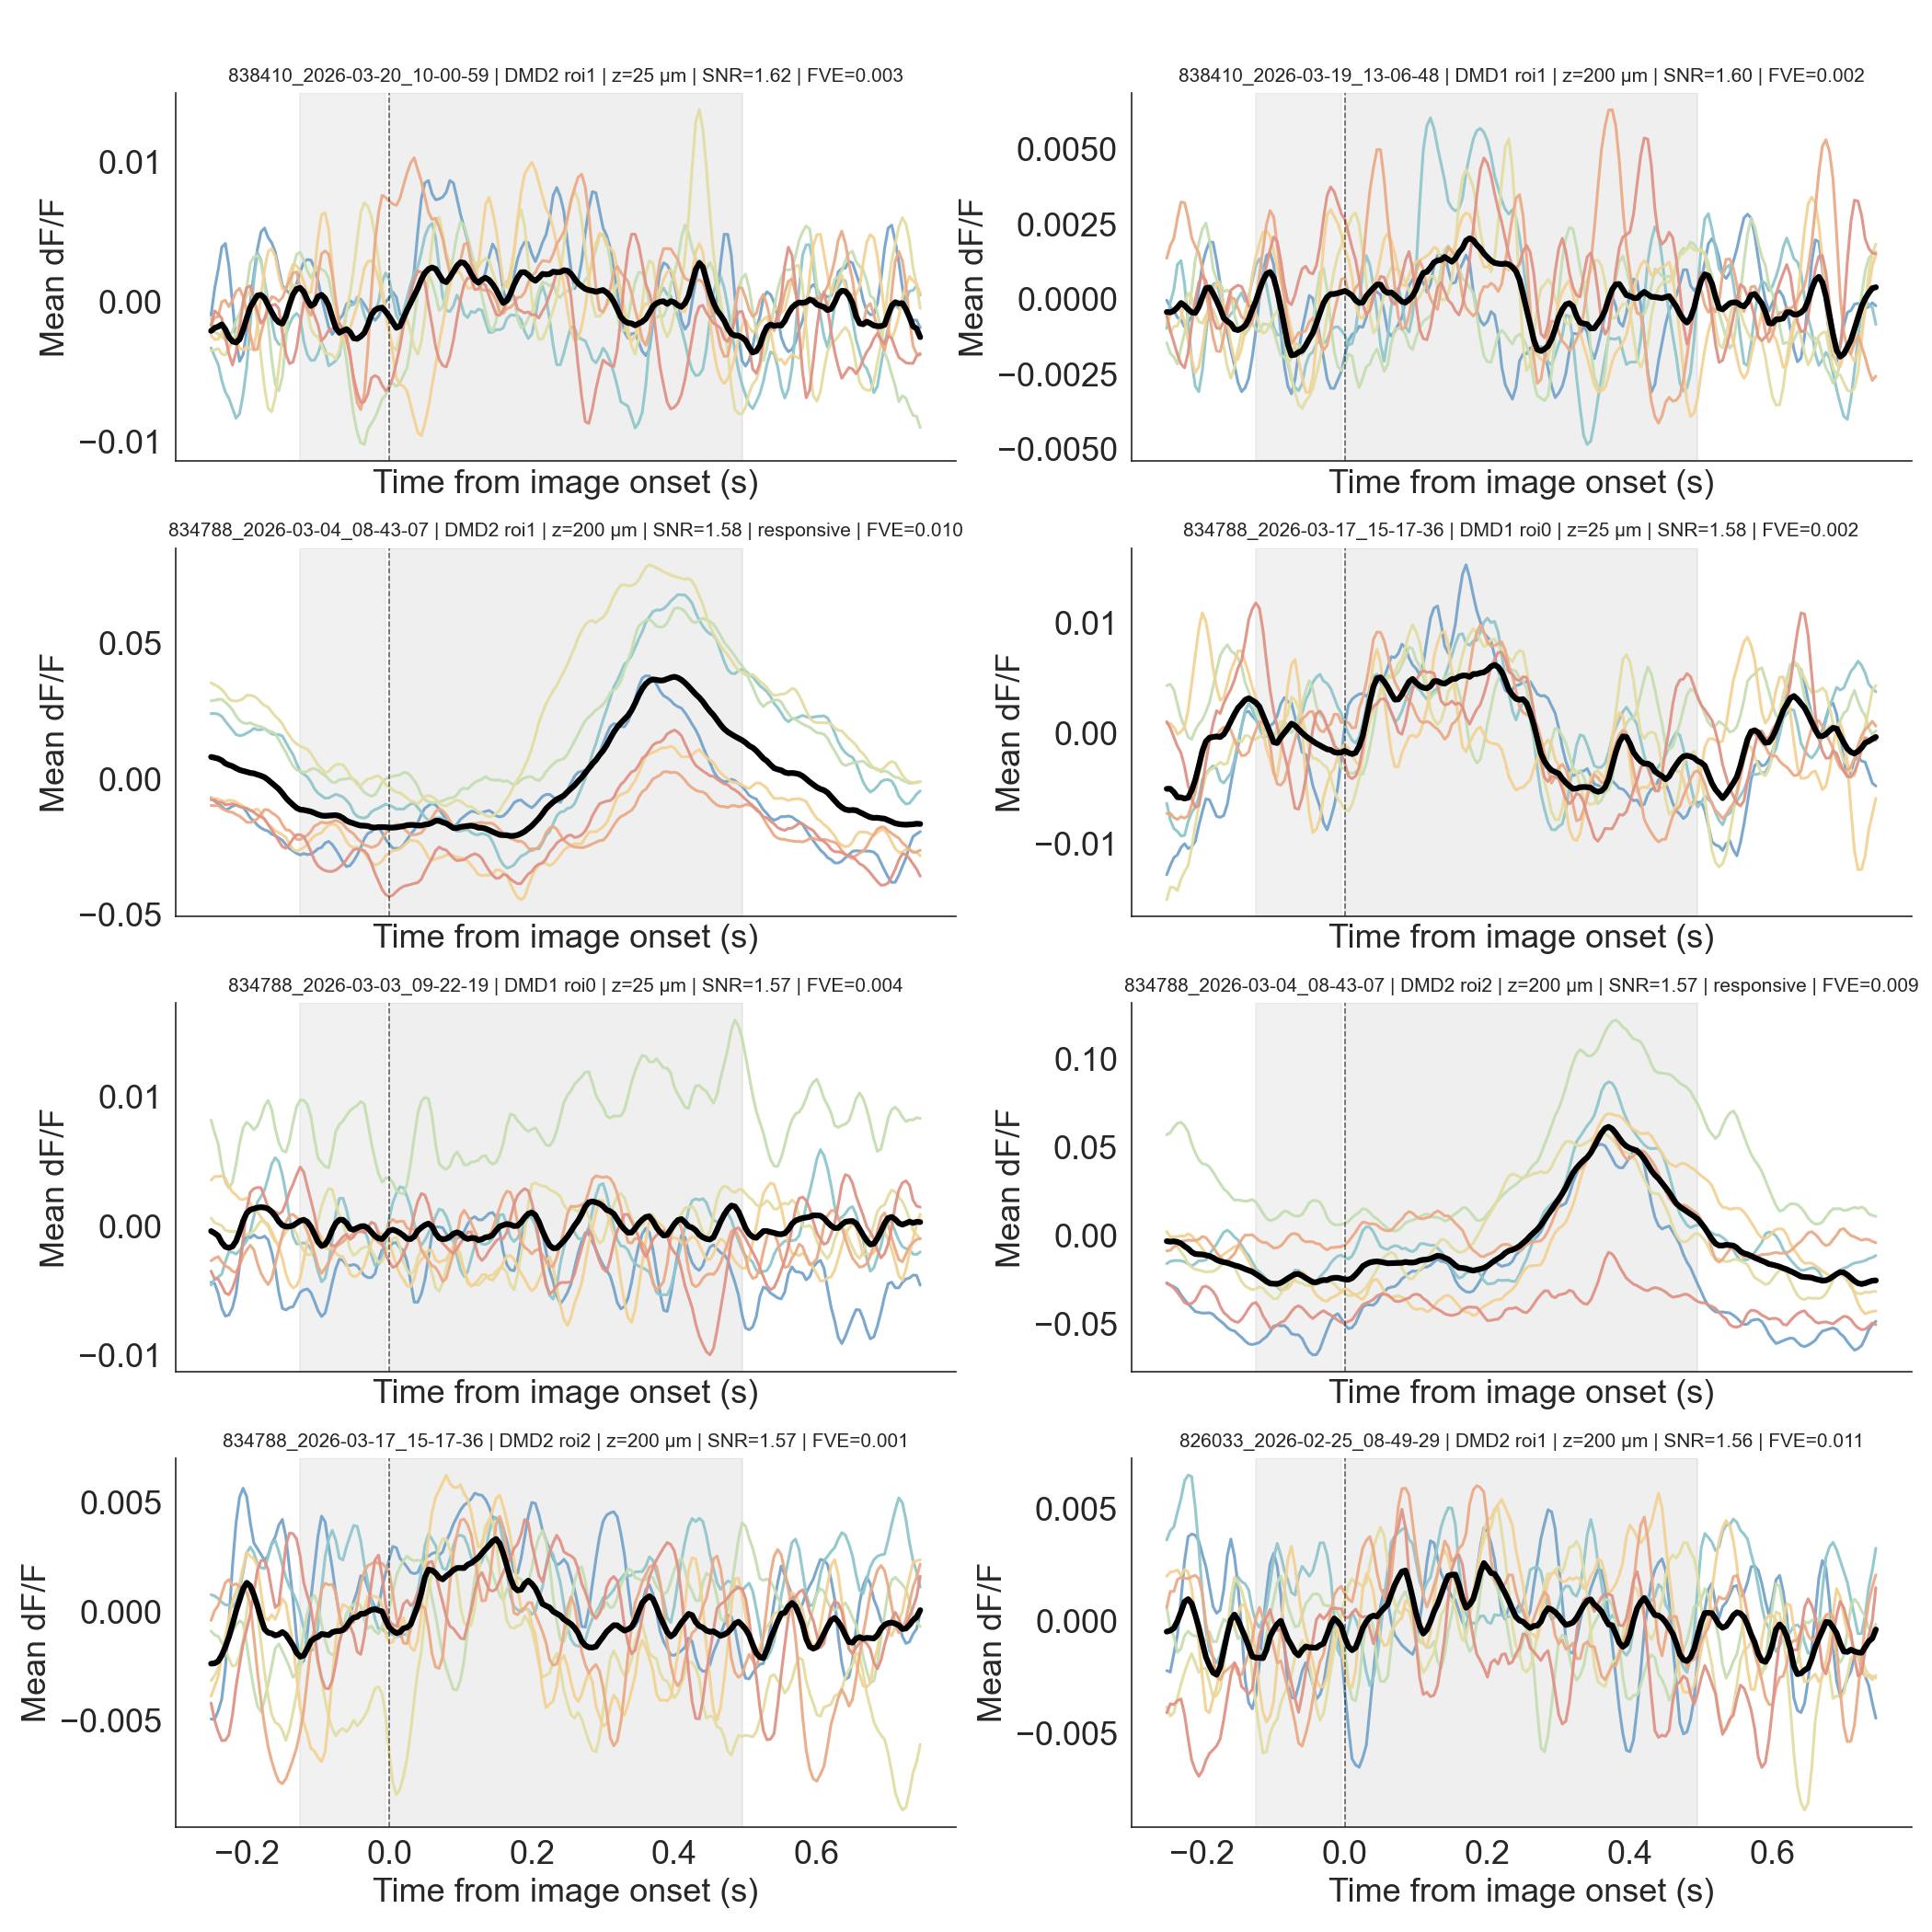

In [8]:
example_payloads = sorted(example_payloads, key=lambda x: x["robust_snr"], reverse=True)[:n_example_somas]

if len(example_payloads) > 0:
    ncols = 2
    nrows = int(np.ceil(len(example_payloads) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, ex in zip(axes, example_payloads):
        image_items = list(ex["image_mean_dict"].items())
        colors = list(islice(cycle(image_palette), len(image_items)))

        stacked = []
        for color, (image_name, trace) in zip(colors, image_items):
            tr = smooth_trace(trace, smooth_window)
            stacked.append(tr)
            ax.plot(ex["time_image"], tr, color=color, lw=1.5, alpha=0.95)

        grand_mean = np.nanmean(np.vstack(stacked), axis=0)
        ax.plot(ex["time_image"], grand_mean, color="k", lw=3)

        ax.axvline(0, color="k", lw=0.75, ls="--", alpha=0.6)
        ax.axvspan(ex["time_image"][baseline_slice.start], ex["time_image"][baseline_slice.stop - 1],
                   color="0.85", alpha=0.35, zorder=-10)
        ax.axvspan(ex["time_image"][response_slice.start], ex["time_image"][response_slice.stop - 1],
                   color="0.6", alpha=0.15, zorder=-10)

        title_bits = [
            f"{ex['session_id']}",
            f"{ex['dmd']} roi{ex['roi_id']}",
            f"z={ex['depth_um']:.0f} µm" if np.isfinite(ex["depth_um"]) else "z=nan",
            f"SNR={ex['robust_snr']:.2f}",
        ]
        if ex["responsive"]:
            title_bits.append("responsive")
        if np.isfinite(ex["image_fve"]):
            title_bits.append(f"FVE={ex['image_fve']:.3f}")

        ax.set_title(" | ".join(title_bits), fontsize=10)
        ax.set_xlabel("Time from image onset (s)")
        ax.set_ylabel("Mean dF/F")
        sns.despine(ax=ax)

    for ax in axes[len(example_payloads):]:
        ax.axis("off")

    fig.suptitle("Highest-SNR soma example mean image responses (top-ranked soma skipped)", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

In [9]:
responsive = soma_results[soma_results["responsive"]==True]
responsive.sort_values('image_selective')

,subject_id,session_id,session_type,dmd,depth_um,roi_id,roi_name,robust_snr,responsive,n_responsive_images,best_image,best_delta,selectivity_p,image_fve,n_trials_used_for_selectivity,selectivity_q,image_selective
25,834788,834788_2026-03-02_10-18-42,familiar,DMD1,25.0,0,DMD1_roi0000,1.541386,True,1,stimuli\images_A\imk00459.tiff,0.003352,0.408591,0.005295,1180,0.841431,False
34,834788,834788_2026-03-03_09-22-19,familiar,DMD2,200.0,3,DMD2_roi0003,1.480230,True,1,stimuli\images_A\imk01057.tiff,0.003145,0.106893,0.009023,1179,0.385656,False
35,834788,834788_2026-03-04_08-43-07,familiar,DMD1,25.0,0,DMD1_roi0000,1.505458,True,2,stimuli\images_A\imk00942.tiff,0.025801,0.050949,0.010890,1180,0.288711,False
37,834788,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,1,DMD2_roi0001,1.584490,True,2,stimuli\images_A\imk00459.tiff,0.018443,0.067932,0.009719,1181,0.320790,False
38,834788,834788_2026-03-04_08-43-07,familiar,DMD2,200.0,2,DMD2_roi0002,1.565716,True,3,stimuli\images_A\imk00459.tiff,0.045506,0.108891,0.009132,1181,0.385656,False
45,834788,834788_2026-03-19_09-05-56,novel+,DMD1,200.0,1,DMD1_roi0001,1.491969,True,2,stimuli\images_B\41006.tiff,0.010608,0.082917,0.009747,1182,0.335617,False
64,838410,838410_2026-03-03_13-49-07,familiar,DMD1,25.0,0,DMD1_roi0000,1.478809,True,5,stimuli\images_A\imk00459.tiff,0.011764,0.218781,0.007008,1180,0.581138,False
12,826033,826033_2026-02-24_14-14-45,familiar,DMD1,25.0,0,DMD1_roi0000,1.471734,True,3,stimuli\images_A\imk01643.tiff,0.007280,0.002997,0.017491,1178,0.048523,True
27,834788,834788_2026-03-02_10-18-42,familiar,DMD2,200.0,1,DMD2_roi0001,1.461901,True,2,stimuli\images_A\imk00895.tiff,0.023741,0.000999,0.038203,1180,0.028305,True
55,838410,838410_2026-03-02_12-40-55,familiar,DMD1,25.0,0,DMD1_roi0000,1.444897,True,4,stimuli\images_A\imk01097.tiff,0.030237,0.000999,0.032505,1179,0.028305,True


In [10]:
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Shuskan2',n_colors=4)
cp = [cp[0],cp[-1]]

<IPython.core.display.Javascript object>


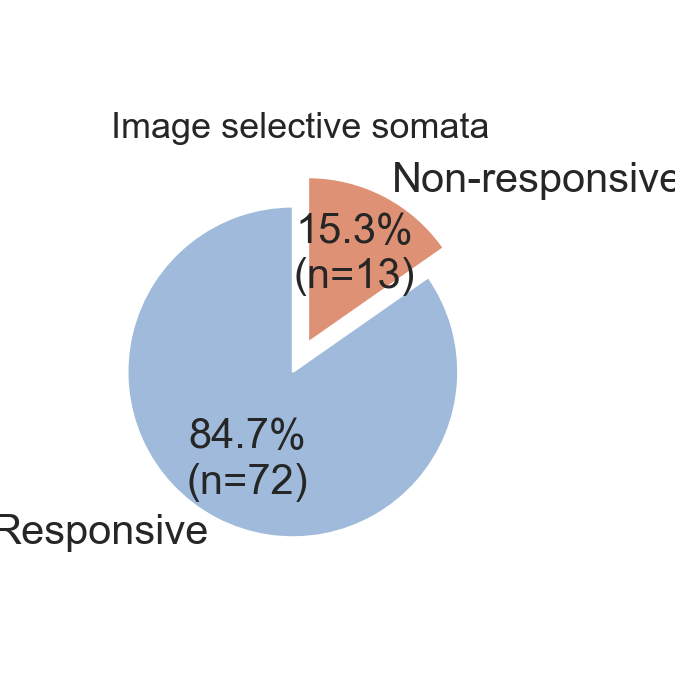

In [14]:
resp_counts = soma_results["responsive"].value_counts().reindex([False, True], fill_value=0)
resp_labels = ["Responsive", "Non-responsive"]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
wedges, texts, autotexts = ax.pie(
    resp_counts.values,
    labels=resp_labels,
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(round(pct/100 * resp_counts.sum()))})",
    startangle=90,
    colors = cp,
    explode=[0.1,0.1],
    textprops={"fontsize": 20},
)
ax.set_title("Image selective somata")
plt.tight_layout()
plt.show()

filen = 'response_pie'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

In [ ]:
soma_results

In [12]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [ ]:
soma_results.to_csv(os.path.join(Path(savepath).parent/'data','soma_results.csv'))